# Raw data

In this notebook we are going to:

1) **describe variables according to their types:** interval-scaled, binary, nominal, ordinal, ratio-scaled. 
    * Be aware that there are specific methods suitable to each type of variable.

2) **Preliminary analysis (summaries, histograms, boxplots, spread measures, density).**
    * These are interesting to be applied to the raw data to “uncover” inconsistencies, outliers, duplicates etc.

3) **List of main changes needed to be performed with the raw data.**


## 1. describe variables according to their types: interval-scaled, binary, nominal, ordinal, ratio-scaled. 

### Some Theoretical notes

| Categoria | Tipo de Atributo | Significado | Operações Possíveis | Exemplos Simples |
| :---: | :---: | :--- | :--- | :--- |
| **Categórico** | **Nominal** | Rótulos/Nomes sem ordem. | Igualdade (=) e Diferença (!=). | Cor dos olhos, ID de Funcionário, Sexo/Género, Código Postal. |
| **Categórico** | **Ordinal** | Rótulos/Nomes com ordem. | Igualdade (=), Diferença (!=), Ordem (<, >). | Nível de satisfação, Graus académicos (A, B, C), Classificação (1.º, 2.º). |
| **Numérico** | **Interval** | Ordem e diferença significativa. Zero é arbitrário. | Ordem, Soma (+) e Subtração (-). Média é possível. | Temperatura (°C ou °F), Datas de Calendário. |
| **Numérico** | **Ratio** | Ordem, diferença significativa e zero absoluto. | Todas as operações: Ordem, Soma, Subtração, Multiplicação (*) e Divisão (/). | Idade, Peso, Altura, Tempo, Número de clientes, Temperatura em Kelvin. |


1. ```Categóricos Qualitativos```
    * Estes **atributos** representam **categorias** ou **grupos**.
        * ```Nominal```
            * Significado: Os valores são apenas **nomes** ou **labels**. A única coisa que podemos fazer é verificar se são **iguais ($\text{=}$)** ou **diferentes (!=)**.
            * Não há ordem, nem é possível fazer operações matemáticas como soma ou subtração.
        * ```Ordinal```
            * Significado: Além de serem diferentes, os valores têm uma **ordem** ou classificação.
            * Podemos dizer que um é **maior ($\text{>}$)** ou **menor ($\text{<}$)** que o outro.
            * No entanto, a distância entre os valores não é significativa ou não pode ser medida de forma consistente.
2. ```Numéricos Quantitativos```
    * Estes **atributos** representam **quantidades mensuráveis**.
        * ```Intervalo```
            * Significado: Os valores têm ordem, e a **diferença** entre dois valores é **significativa** (podemos subtrair e somar).
            * No entanto, o **zero é arbitrário** (**não significa a ausência total da propriedade**), o que **impede a realização de ratios** (divisão).
        * ```Ratio```
            * Significado: É o nível mais completo. Tem ordem, diferenças significativas, e um **zero absoluto** (**o zero significa a ausência total da propriedade**).
            * Isto permite que **todos os tipos de operações sejam aplicáveis**, incluindo **ratios (multiplicação e divisão)**.

### Variable Type description

| Atributo |  Descrição | Nominal |  Ordinal | Interval |  Ratio | Nota|
| :-------- | :-------- | :-------: | :-------: | :-------: | :-------: |  :-------: | 
| **ID**|  anonymized patient ID | X | | | |
| **Peso**| patient weight | | | | X |
| **Altura**| patient height  | | | | X | 
| **IMC**| body mass index (BMI)| | | | X |
| **Atendimento**| date of visit | | X | ||
| **DN**| birth date | | X | | |
| **IDADE**| age | | | | X |
| **Convenio**|  health care insurance  | X | | | |
| **PULSOS**| pulses  | X| | | |
| **PA SISTOLICA**|  systolic blood pressure (SBP) | | | X| | Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o SBP = 0 ==> que a pessoa esta morta) 
| **PA DIASTOLICA**| diastolic blood pressure (DBP) | | | X | | 	Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o DBP = 0 ==> erro de medição)
| **PPA**| result SBP/DBP | X | |  |  |
| **NORMAL x ANORMAL**| absence or presence of pathology |  X | | | |
| **B2**| type of the second heart sound | X | | | |
| **SOPRO**|  murmur type | X | | | |
| **FC**| cardiac frequency | | | X | | Não é Ratio, porque o zero não significa a ausencia total da propriedade, i.e. zero é arbitrario (visto que o FC = 0 ==> que a pessoa esta morta)
| **HDA1**| histoy of disease 1 | X | | | |
| **HDA2**|  histoy of disease 2 (other history) | X | | | |
| **SEXO**|  patient gender | X | | | |
| **MOTIVO1**| first reason for being forwarded to the cardiology clinic | X | | | |
| **MOTIVO2**| second reason for being forwarded to the cardiology clinic  | X | | | |

### References values (detect impossible values)

#### Systolic Blood Presure (SBP) & Dystolic Blood Presure (DBP)

* **Systolic Blood Presure (SBP)**
    * Used **blood_presure_children.pdf** (in info directory) to create a map (age-sbp-map.json) and defined tha values that do not enter [**first_value-10,last_value+10**] are removed 
* **Dystolic Blood Presure (DBP)**
    * Did the same as before

> The **first_value** and **last_value** are highlited in the image bellow 

![alt text](img/image.PNG)

> Check **sbp-dbp-reference-values-map** (in Data-structures directory) to see the mapping

#### Result of SBP - DBP (PPA)

* Used the information present in this table: https://www.ncbi.nlm.nih.gov/books/NBK9633/table/A32/ (although it is for adults, i could not find any for the specific age group we want, 2-19)

![alt text](img/image-3.PNG)


#### Boss Mass Index (BMI) Percentile

For the BMI we defined the folowing categories:


* **Low Weigth** -> < Less than the 5th percentile
* **Normal** -> >= 5th and < 85th percentile
* **Overweigth** -> >= 85th percentile to less than the 95th percentile
* **Obese** -> >= 95th percentil


> These categories were adjusted from the information present in https://www.cdc.gov/bmi/child-teen-calculator/bmi-categories.html#cdc_generic_section_3-bmi-calculator, **paper-2.pdf** and **bmi-reference.pdf**. The reference values were saved in **bmi-references-values.json** (in Data-structures directory)

> Note: **bmi-references-values.json** values were obtained from the last two graphics of **bmi-reference.pdf** (the values were obtained by hand)



#### Cardiac Frequency (CF)

Followed the references values found in https://www.forbes.com/health/wellness/normal-heart-rate-by-age/

![alt text](img/image-2.PNG)


## 2. Preliminary analysis (summaries, histograms, boxplots, spread measures, density).


### 2.1 Load data

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import missingno as msno
sns.set_theme(style='darkgrid')
import matplotlib.pyplot as plt

In [3]:
data = pd.read_excel('Assignment/DataSets/UCMF.xls')

# Trocei valores invalidos (erros do excel) por np.nan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
data.replace('#VALUE!', np.nan, inplace=True)
data.replace('#!VALUE', np.nan, inplace=True)

# Corrigir dados que tem tipo incorreto (as vezes ao importar datasets isto pode acontecer)
data['IDADE'] = data['IDADE'].astype(float)

data = data.rename(columns={
    'IDADE': 'Idade',
    'PULSOS':'Pulsos',
    'PA SISTOLICA': 'SBP',
    'PA DIASTOLICA': 'DBP',
    'PPA': 'Result SBP-DBP',
    'NORMAL X ANORMAL': 'Patologia',
    'SOPRO' : 'Sopro',
    'SEXO':'Sexo',
    'HDA 1': 'HDA1',
    'MOTIVO1' : 'Motivo1',
    'MOTIVO2': 'Motivo2'
})



In [4]:
data.head()

,ID,Peso,Altura,IMC,Atendimento,DN,Idade,Convenio,Pulsos,SBP,...,Result SBP-DBP,Patologia,B2,Sopro,FC,HDA1,HDA2,Sexo,Motivo1,Motivo2
0,1,5.0,51,19.0,11/05/06,30/03/06,0.12,GS,Normais,NaN,...,Não Calculado,Anormal,Normal,Sistólico,112,Palpitacao,NaN,M,6 - Suspeita de cardiopatia,6 - Palpitação/taquicardia/arritmia
1,2,3.5,50,14.0,25/05/05,19/05/05,0.02,GS,Normais,NaN,...,Não Calculado,Anormal,Normal,ausente,128,Dispneia,NaN,M,6 - Suspeita de cardiopatia,6 - Dispnéia
2,3,0.0,0,NaN,12/06/01,08/05/05,-4.05,SULA,Normais,NaN,...,Não Calculado,Anormal,Normal,Sistólico,88,Assintomático,NaN,M,2 - Check-up,NaN
3,4,8.1,65,19.0,15/10/09,21/04/09,0.50,NaN,Normais,NaN,...,Não Calculado,Anormal,Normal,ausente,92,Assintomático,NaN,M,5 - Parecer cardiológico,NaN
4,5,39.5,142,20.0,23/01/09,24/10/99,9.60,Sulam,Normais,85.0,...,Normal,Anormal,Normal,ausente,90,NaN,NaN,M,5 - Parecer cardiológico,5 - Atividade física


### 2.2 Summaries

In [5]:
data.shape

(17873, 21)

In [6]:
data.columns

Index(['ID', 'Peso', 'Altura', 'IMC', 'Atendimento', 'DN', 'Idade', 'Convenio',
       'Pulsos', 'SBP', 'DBP', 'Result SBP-DBP', 'Patologia', 'B2', 'Sopro',
       'FC', 'HDA1', 'HDA2', 'Sexo', 'Motivo1', 'Motivo2'],
      dtype='object')

In [7]:
data.info(verbose=True,max_cols=21)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17873 entries, 0 to 17872
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              17873 non-null  int64  
 1   Peso            17555 non-null  float64
 2   Altura          17873 non-null  int64  
 3   IMC             13146 non-null  float64
 4   Atendimento     16890 non-null  object 
 5   DN              16497 non-null  object 
 6   Idade           16377 non-null  float64
 7   Convenio        12569 non-null  object 
 8   Pulsos          16675 non-null  object 
 9   SBP             10143 non-null  float64
 10  DBP             10133 non-null  float64
 11  Result SBP-DBP  16160 non-null  object 
 12  Patologia       16705 non-null  object 
 13  B2              16694 non-null  object 
 14  Sopro           16706 non-null  object 
 15  FC              15832 non-null  object 
 16  HDA1            12459 non-null  object 
 17  HDA2            652 non-null   

In [8]:
print('Overview of Columns:')
data.describe().transpose()

Overview of Columns:


,count,mean,std,min,25%,50%,75%,max
ID,17873.0,8937.000000,5159.635016,1.00,4469.00,8937.00,13405.00,17873.00
Peso,17555.0,21.163520,18.061021,-40.00,6.60,18.00,31.00,157.00
Altura,17873.0,83.865216,56.583610,0.00,36.00,99.00,130.00,198.00
IMC,13146.0,17.806329,12.071950,0.00,15.00,17.00,19.00,848.00
Idade,16377.0,6.011970,7.827266,-113.18,2.18,5.64,9.97,71.81
SBP,10143.0,101.314108,15.510066,10.00,90.00,100.00,110.00,990.00
DBP,10133.0,62.303661,8.885555,6.00,60.00,60.00,70.00,120.00


#### Checking for duplicates & missing values 

In [9]:
dups = data[data.duplicated()]
print(f'Number of duplicates: {len(dups)}')

Number of duplicates: 0


In [10]:
missing_val = data.isna().sum()
print(missing_val.loc[missing_val > 0])

Peso                318
IMC                4727
Atendimento         983
DN                 1376
Idade              1496
Convenio           5304
Pulsos             1198
SBP                7730
DBP                7740
Result SBP-DBP     1713
Patologia          1168
B2                 1179
Sopro              1167
FC                 2041
HDA1               5414
HDA2              17221
Sexo                  4
Motivo1            1097
Motivo2            4778
dtype: int64


In [11]:
# Calculating missing value percentage in the dataset
missing = data.isna().sum()
mis_per = (missing / len(data)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

                Missing Values  Percentage of Total Values
Peso                       318                        1.78
IMC                       4727                       26.45
Atendimento                983                        5.50
DN                        1376                        7.70
Idade                     1496                        8.37
Convenio                  5304                       29.68
Pulsos                    1198                        6.70
SBP                       7730                       43.25
DBP                       7740                       43.31
Result SBP-DBP            1713                        9.58
Patologia                 1168                        6.53
B2                        1179                        6.60
Sopro                     1167                        6.53
FC                        2041                       11.42
HDA1                      5414                       30.29
HDA2                     17221                       96.

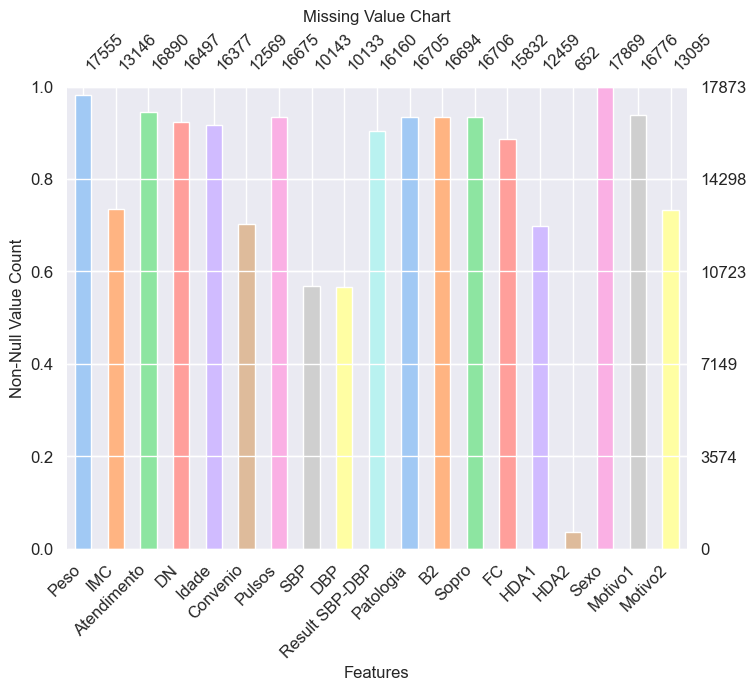

In [12]:
sns.set_palette('pastel')
colors = sns.color_palette()

missing_vals = [col for col in data.columns if data[col].isna().any()]

fig, ax = plt.subplots(figsize = (8, 6))
msno.bar(data[missing_vals], ax = ax, fontsize = 12, color = colors)
ax.set_xlabel('Features', fontsize = 12)
ax.set_ylabel('Non-Null Value Count', fontsize = 12)
ax.set_title('Missing Value Chart', fontsize = 12)
plt.show()

#### Check if dataset is balanced

In [13]:
data.value_counts("Patologia")

Patologia
Normal     9991
Anormal    6712
Normais       1
anormal       1
Name: count, dtype: int64

### 2.3 Visualization

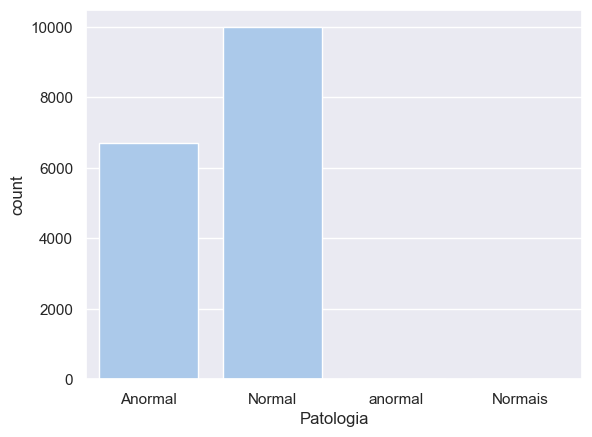

In [14]:
sns.countplot(x='Patologia', data=data, )
plt.show()

#### 2.3.1 Realtion between features with pair plot 

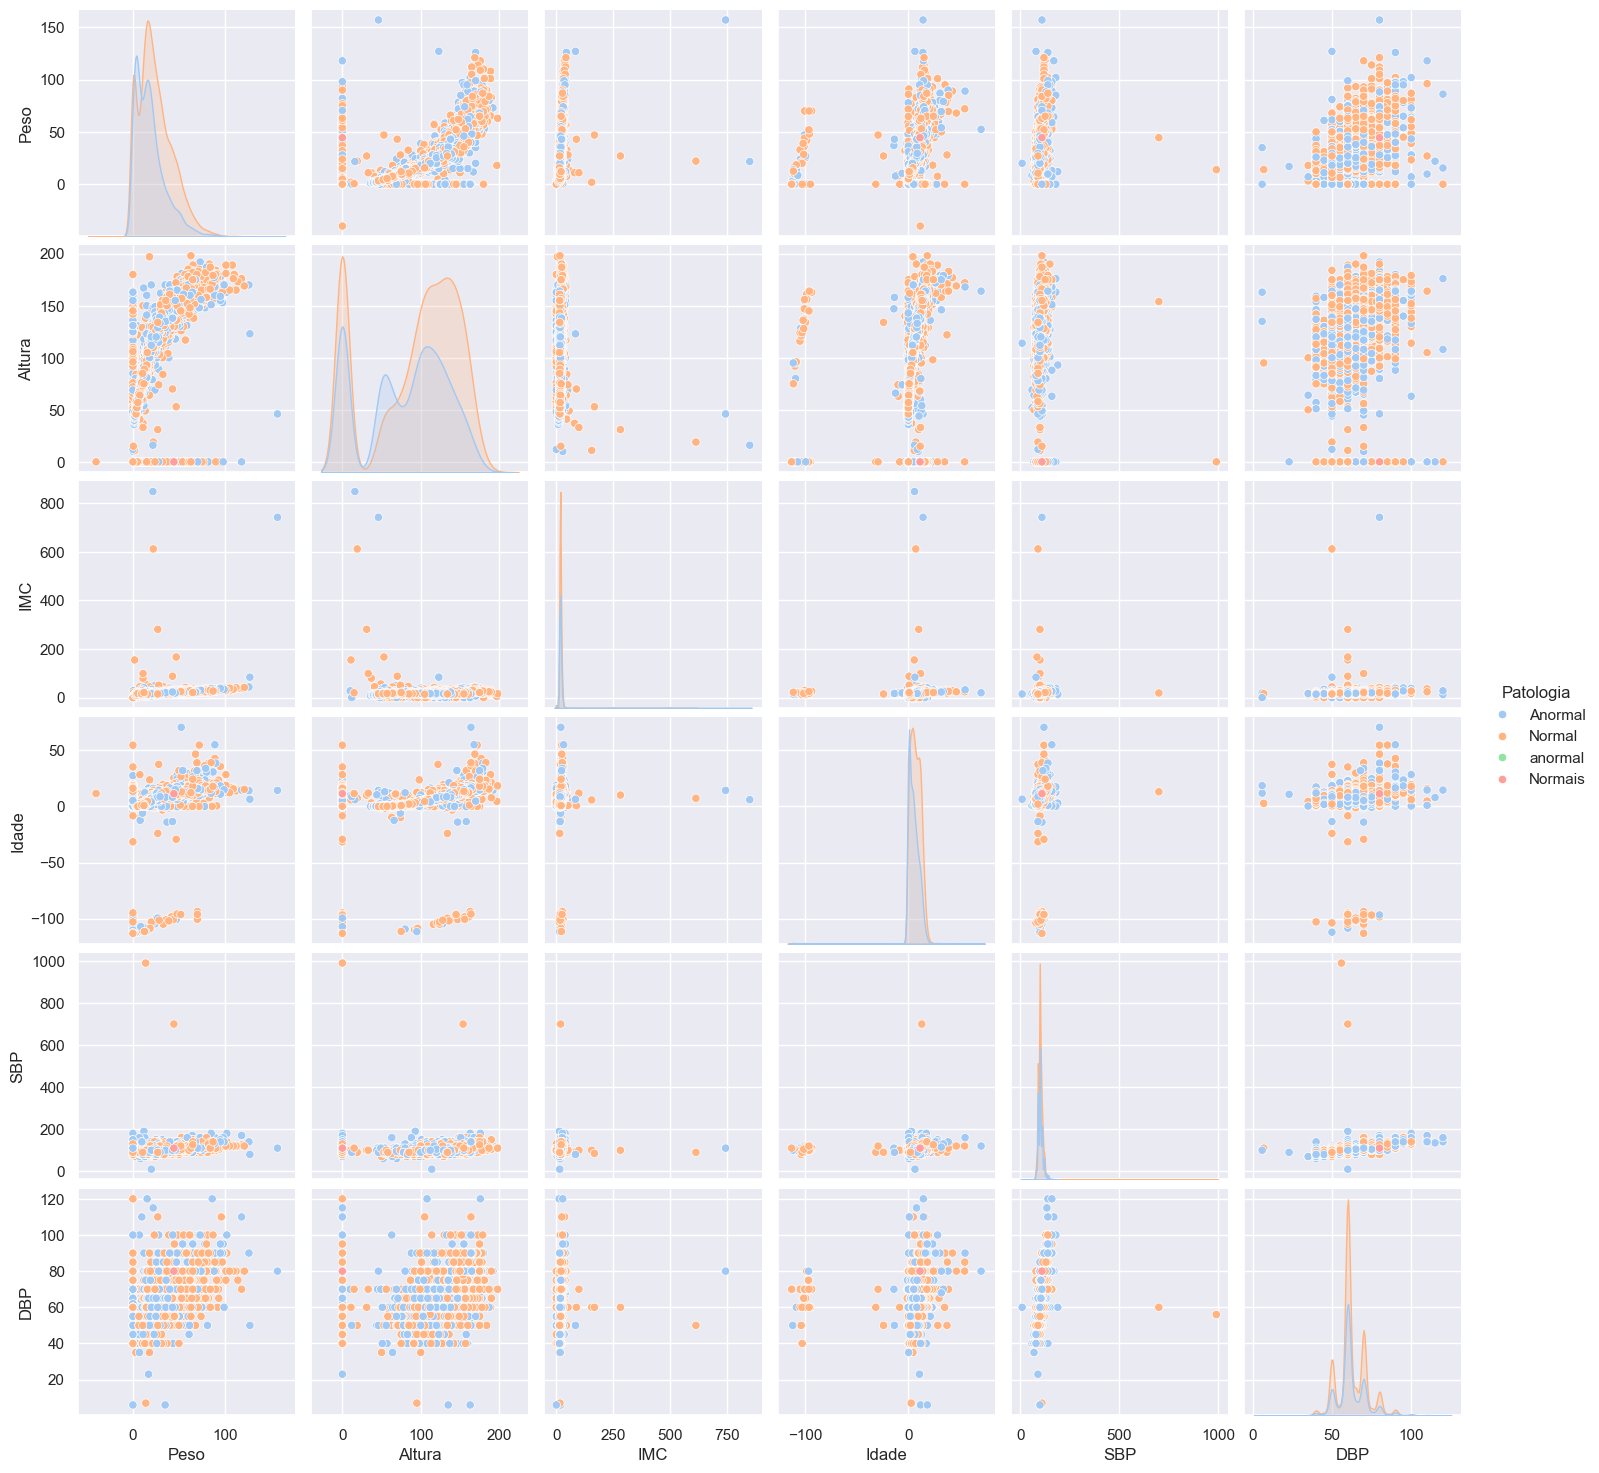

In [15]:
sns.pairplot(data.drop(['ID'], axis = 1),
            hue='Patologia')

Da figura acima, podemos concluir o seguinte ponto principal sobre a **raw data**:
* É evidente a presença de **ruído** e/ou **erros de registo** nos dados, que **manifestam-se como outliers extremos**.
    * Alguns exemplos:
        * Altura a zero:  causa a que se forme uma linha/coluna que representam Altura=0 (o que não é um valor possivel)
        * Pesos negativos : por exemplo na relação entre Peso e Altura.
        * IMC Impossivel : valores de IMC que são impossiveis de atingir (e.g. relação IMC e PA Sistolica tem valor de IMC entre [600,800])
        * etc..
* Não é possivel estabelecer nenhuma relação linear ou padrões claros quando verificamos a relação entre features da **raw data**
    * A unica exceção é a relação entre altura e peso (embora demonstre algum ruido) 

#### 2.3.2 Histograms

Histograms allow seeing the distribution of data for various columns. It can be used for uni as well as bi-variate analysis.

--- Generating Histograms for Numerical Features ---


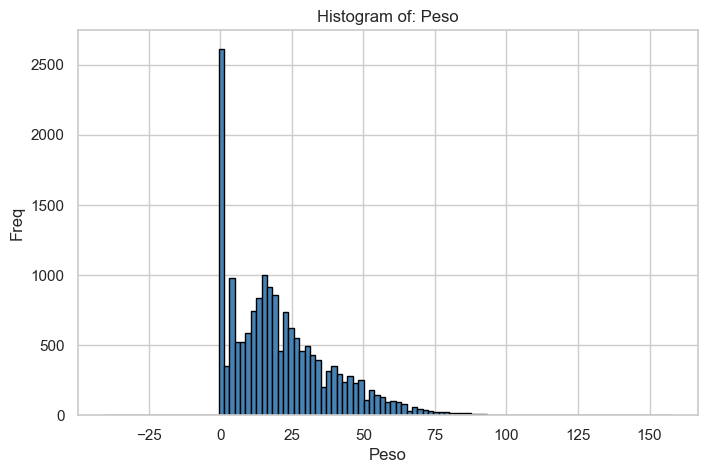

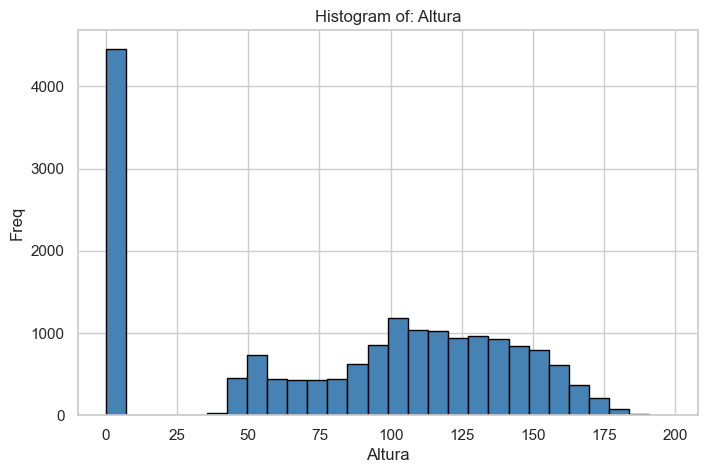

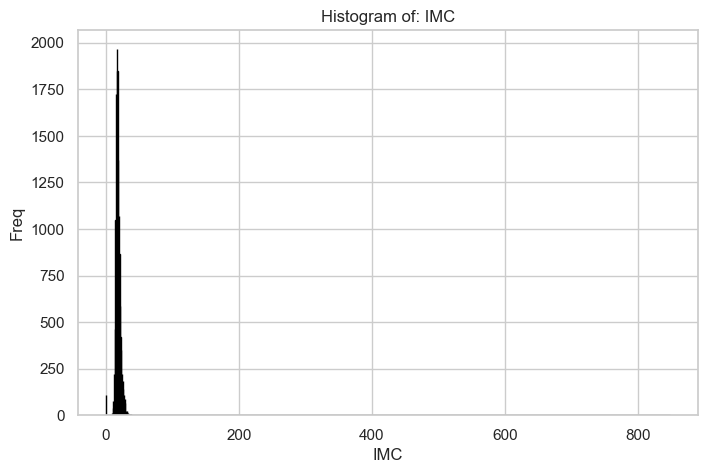

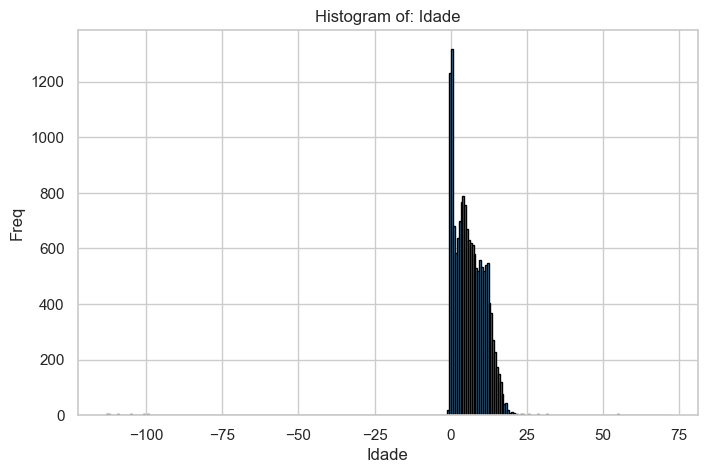

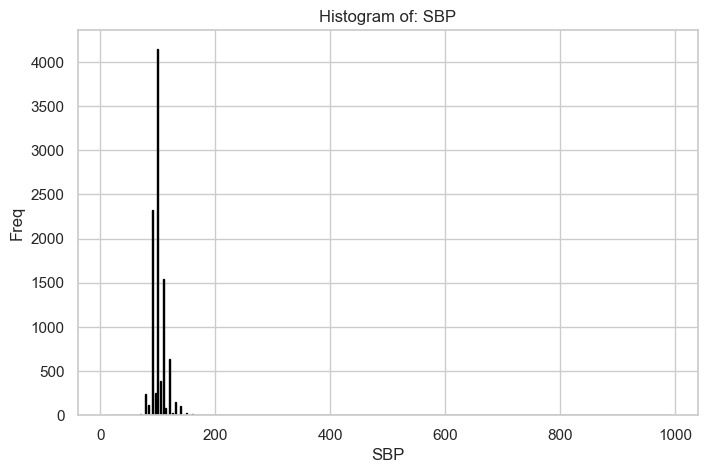

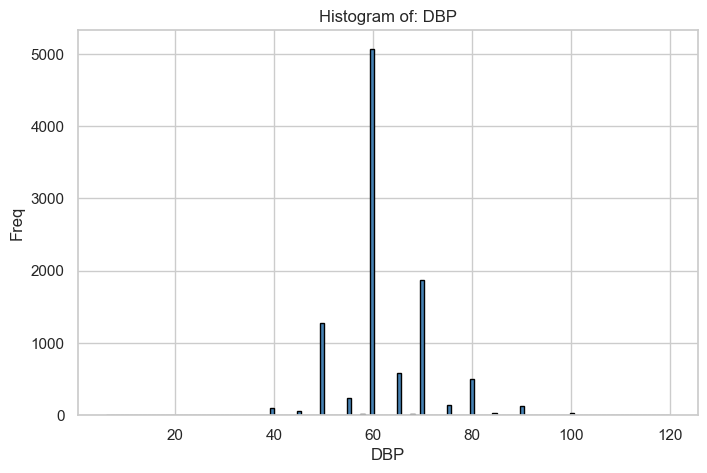

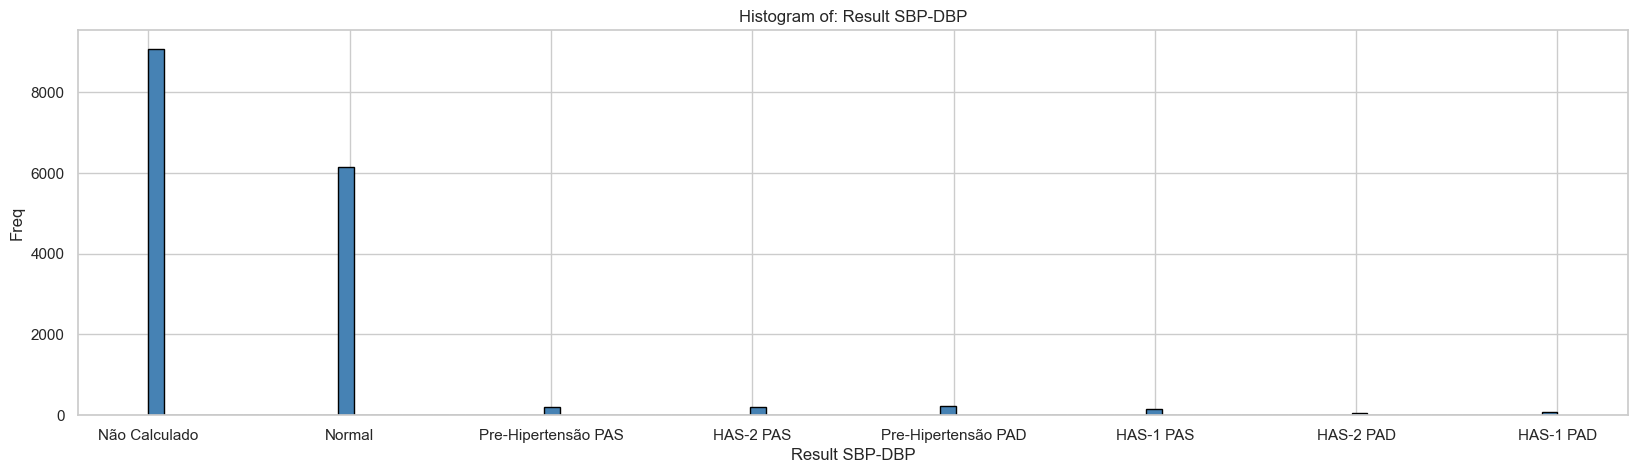

Could make the plot of FC (maybe 'fd' failed): '<=' not supported between instances of 'int' and 'str'


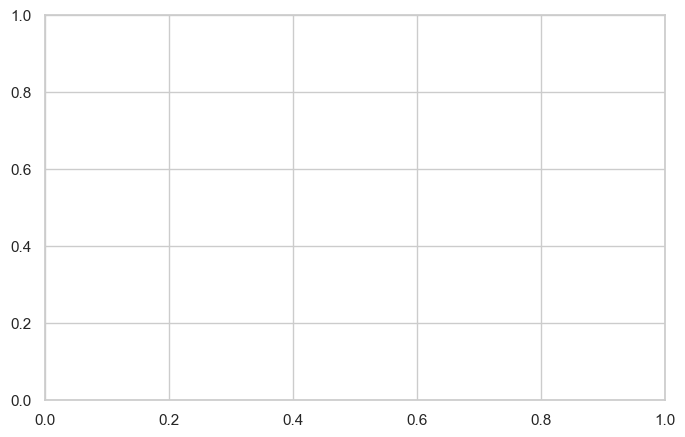


--- Generating Countplot for Categorical Features---


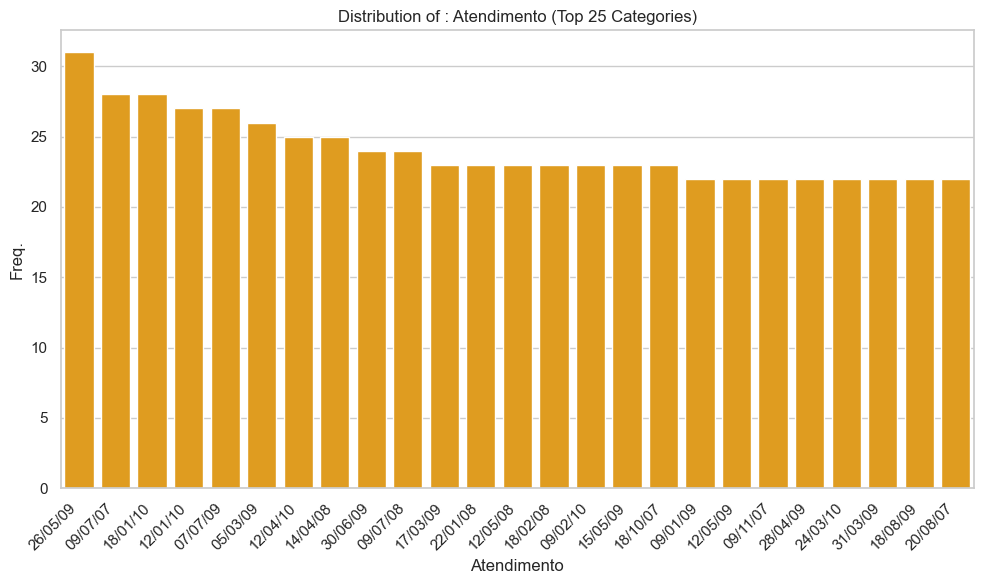

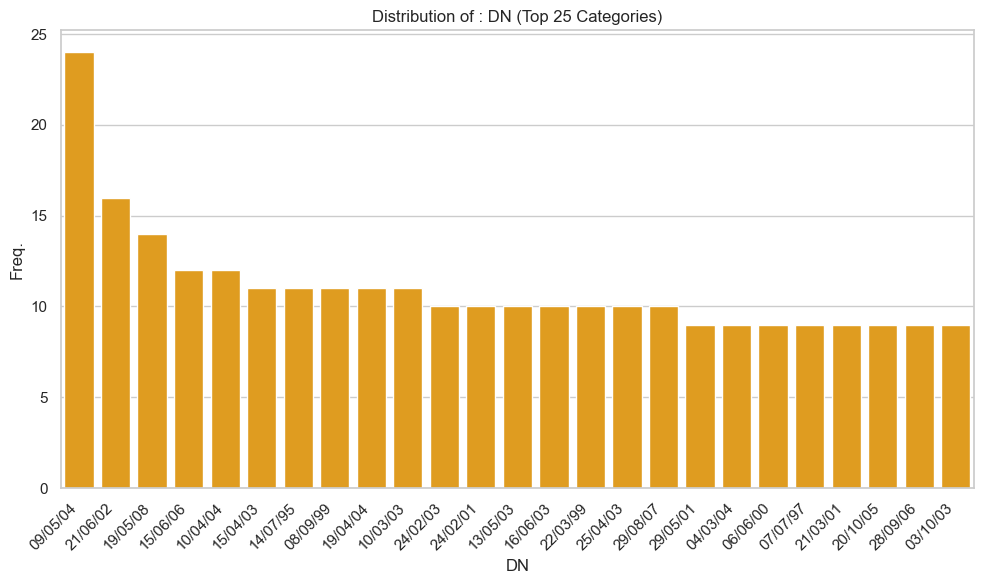

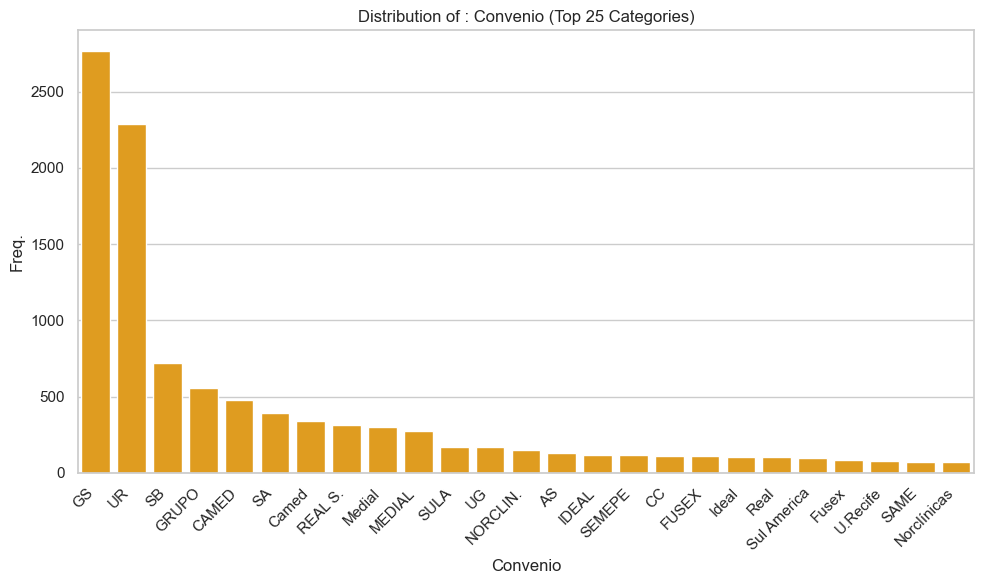

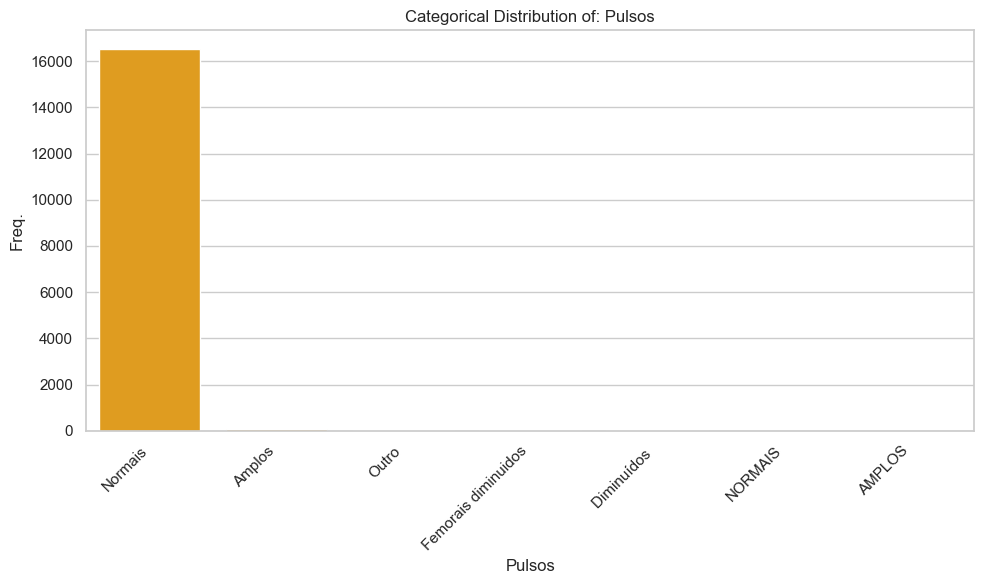

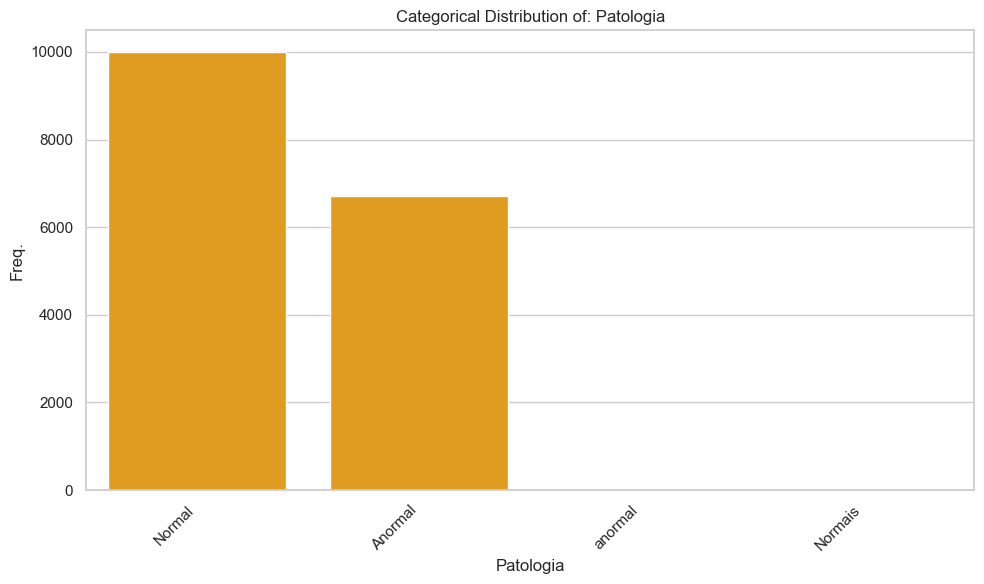

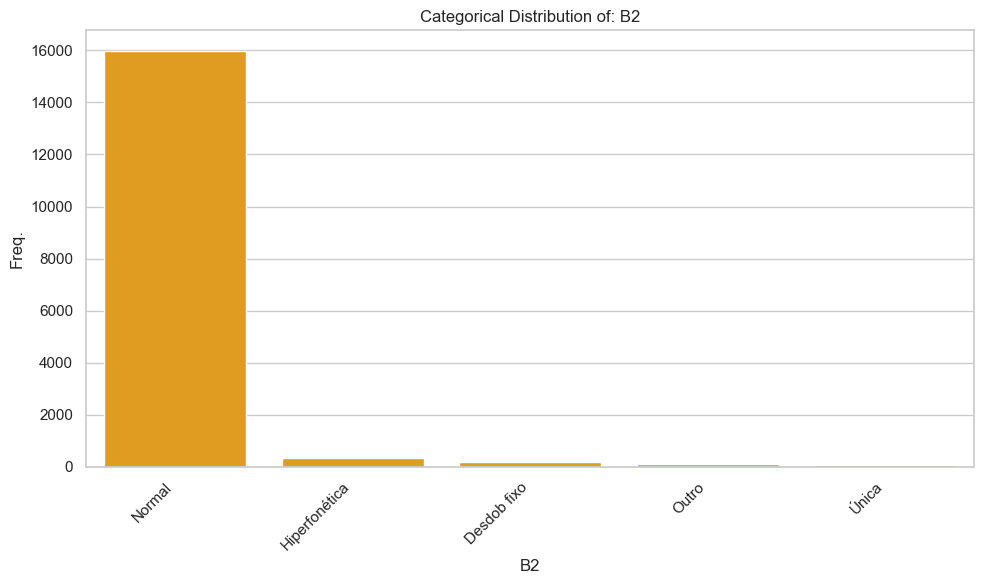

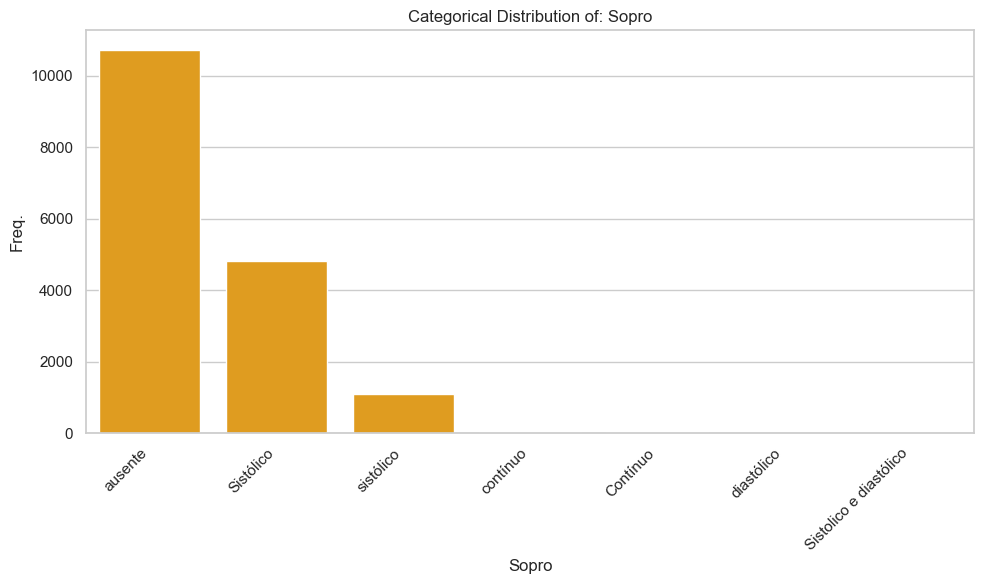

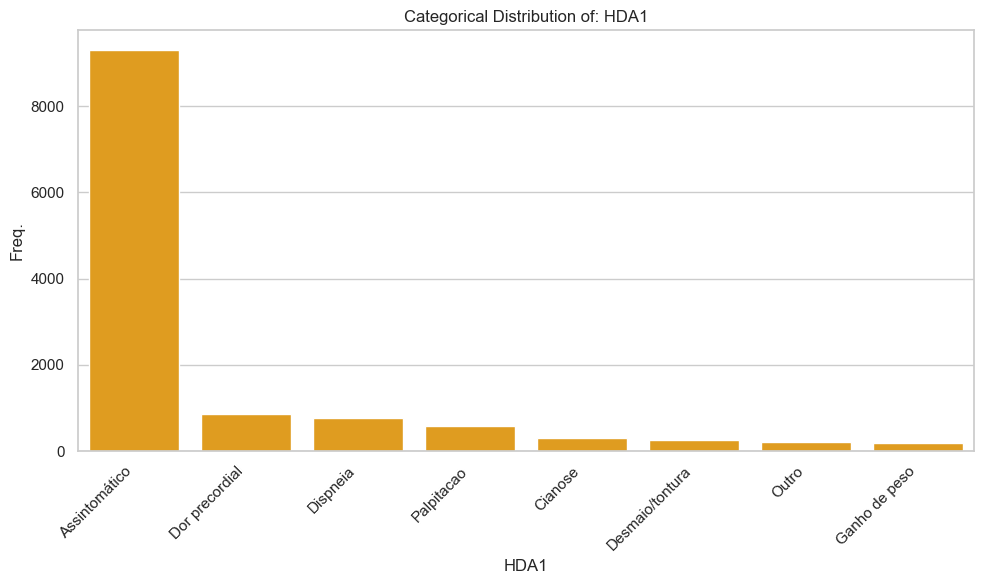

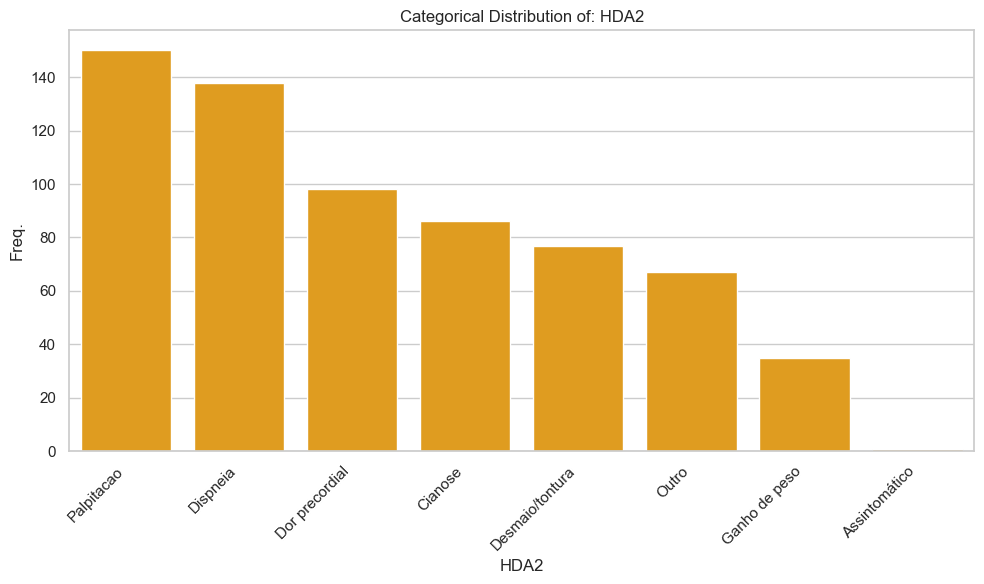

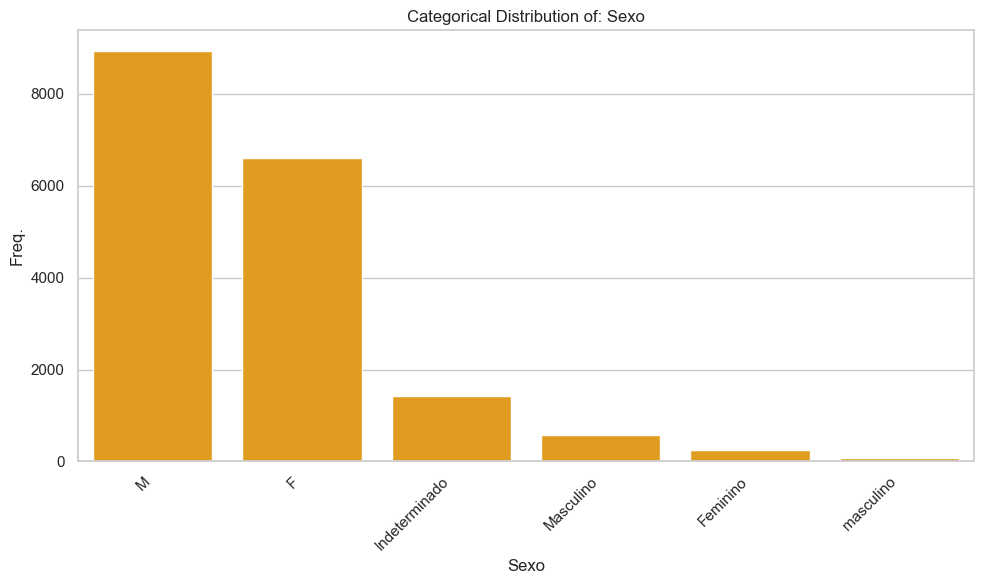

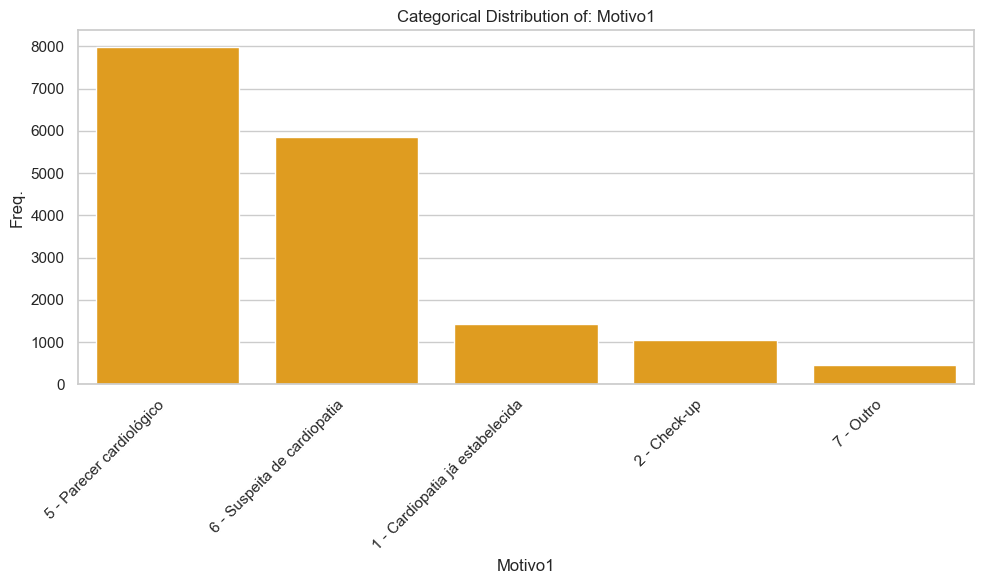

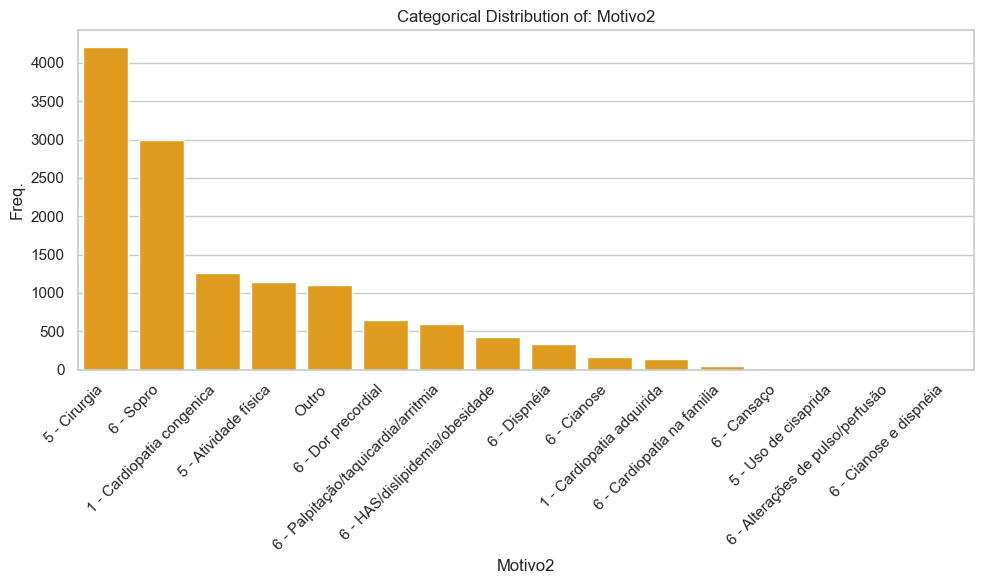

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# 1. Definir as listas de features com base na sua imagem
# (Excluindo 'ID')

# Features Numéricas (Ratio ou Interval) para Histogramas
numeric_features = [
    'Peso', 'Altura', 'IMC', 'Idade', 
    'SBP', 'DBP', 'Result SBP-DBP', 'FC'
]

# Features Categóricas (Nominal) para Gráficos de Barras
# Nota: 'Atendimento' e 'DN' são Intervalo (datas) na tabela,
# mas são melhor visualizados como categorias (countplots).
categorical_features = [
    'Atendimento', 'DN', 'Convenio', 'Pulsos', 
    'Patologia', 'B2', 'Sopro', 
    'HDA1', 'HDA2', 'Sexo', 'Motivo1', 'Motivo2'
]

sns.set_style("whitegrid")

# --- 2. Plot Histograms for numerical features---
print("--- Generating Histograms for Numerical Features ---")
for feature in numeric_features:
    if feature == 'Result SBP-DBP': 
        plt.figure(figsize=(20, 5))
    else:
        plt.figure(figsize=(8, 5))
    
    # Usar .dropna() para remover valores NaN (missing) antes de plotar
    # O 'bins='fd'' (Freedman-Diaconis) pode falhar se houver muitos NaNs
    try:
        data_to_plot = data[feature].dropna()
        plt.hist(data_to_plot, bins='fd', color='steelblue', edgecolor='black')
        plt.title(f'Histogram of: {feature}')
        plt.xlabel(feature)
        plt.ylabel('Freq')
    except Exception as e:
        print(f"Could make the plot of {feature} (maybe 'fd' failed): {e}")
        
    plt.show() 


# --- 3. Plot Countplots for Categorical Features---
print("\n--- Generating Countplot for Categorical Features---")
for feature in categorical_features:
    # Criar uma nova figura para cada plot
    plt.figure(figsize=(10, 6))
    
    # Usar sns.countplot para a visualização categórica "correta"
    
    # Calcular a ordem (do mais frequente para o menos frequente)
    try:
        # Obter o N de categorias únicas
        n_unique = data[feature].nunique()
        
        plot_title = f'Categorical Distribution of: {feature}'
        order = data[feature].value_counts().index
        
        # Ajuste para alta cardinalidade (ex: 'Atendimento', 'DN')
        # Se houver mais de 25 categorias, plotamos apenas as 25 principais
        if n_unique > 25:
            plot_title = f'Distribution of : {feature} (Top 25 Categories)'
            # Pegar o índice das 25 principais
            top_25 = order[:25]
            # Filtrar dados para plotar apenas o top 25
            plot_data = data[data[feature].isin(top_25)]
            sns.countplot(x=feature, data=plot_data, color='orange', order=top_25)
        else:
            # Plotar todas as categorias se forem 25 ou menos
            sns.countplot(x=feature, data=data, color='orange', order=order)
        
        plt.title(plot_title)
        plt.xlabel(feature)
        plt.ylabel('Freq.')
        
        # Rotacionar os labels do eixo X para melhor leitura
        plt.xticks(rotation=45, ha='right')
        
    except Exception as e:
        print(f"Could not plot {feature} (maybe a error of data type): {e}")

    plt.tight_layout() # Ajusta o layout para evitar que os labels sejam cortados
    plt.show() # Exibe o gráfico imediatamente

* Alguns pontos que podemos concluir dos plots acima:
    * Existem alguns valores invalidos nas colunas que impedem fazer o respetivo plot (e.g. FN tem celulas com valores = '150 a 180' e outros com '120')
    * A distribuição de algumas colunas (features) demonstram mais uma vez o ruido presente (e.g. picos a 0 de frequência e altura)
    * A distribuição dos dados categoricos, em alguns casos, faz com que tenha muitos objeto com uma certo valor e poucos com outro (e.g.  a feature Pulsos tem bastantes objetos e as restnates tem significativamente menos)


#### 2.3.3 Boxplots

* Um boxplot serve para visualizar a distribuição de um conjunto de dados. Ele mostra rapidamente 5 estatísticas principais:
    * O valor mínimo
    * O primeiro quartil (Q1 - 25% dos dados)
    * A mediana (Q2 - 50% dos dados, o valor central)
    * O terceiro quartil (Q3 - 75% dos dados)
    * O valor máximo
* É especialmente útil para identificar outliers (valores atípicos) e para comparar a distribuição de vários grupos lado a lado.
* O boxplot é desenhado para uma variável numérica (ex: "salário", "altura", "temperatura").
* No entanto, o seu uso mais comum e poderoso é para comparar essa variável numérica dividida por uma variável categórica (ex: comparar "Peso" (numérica) com a target feature "NORMAL X ANORMAL" (categorica)).

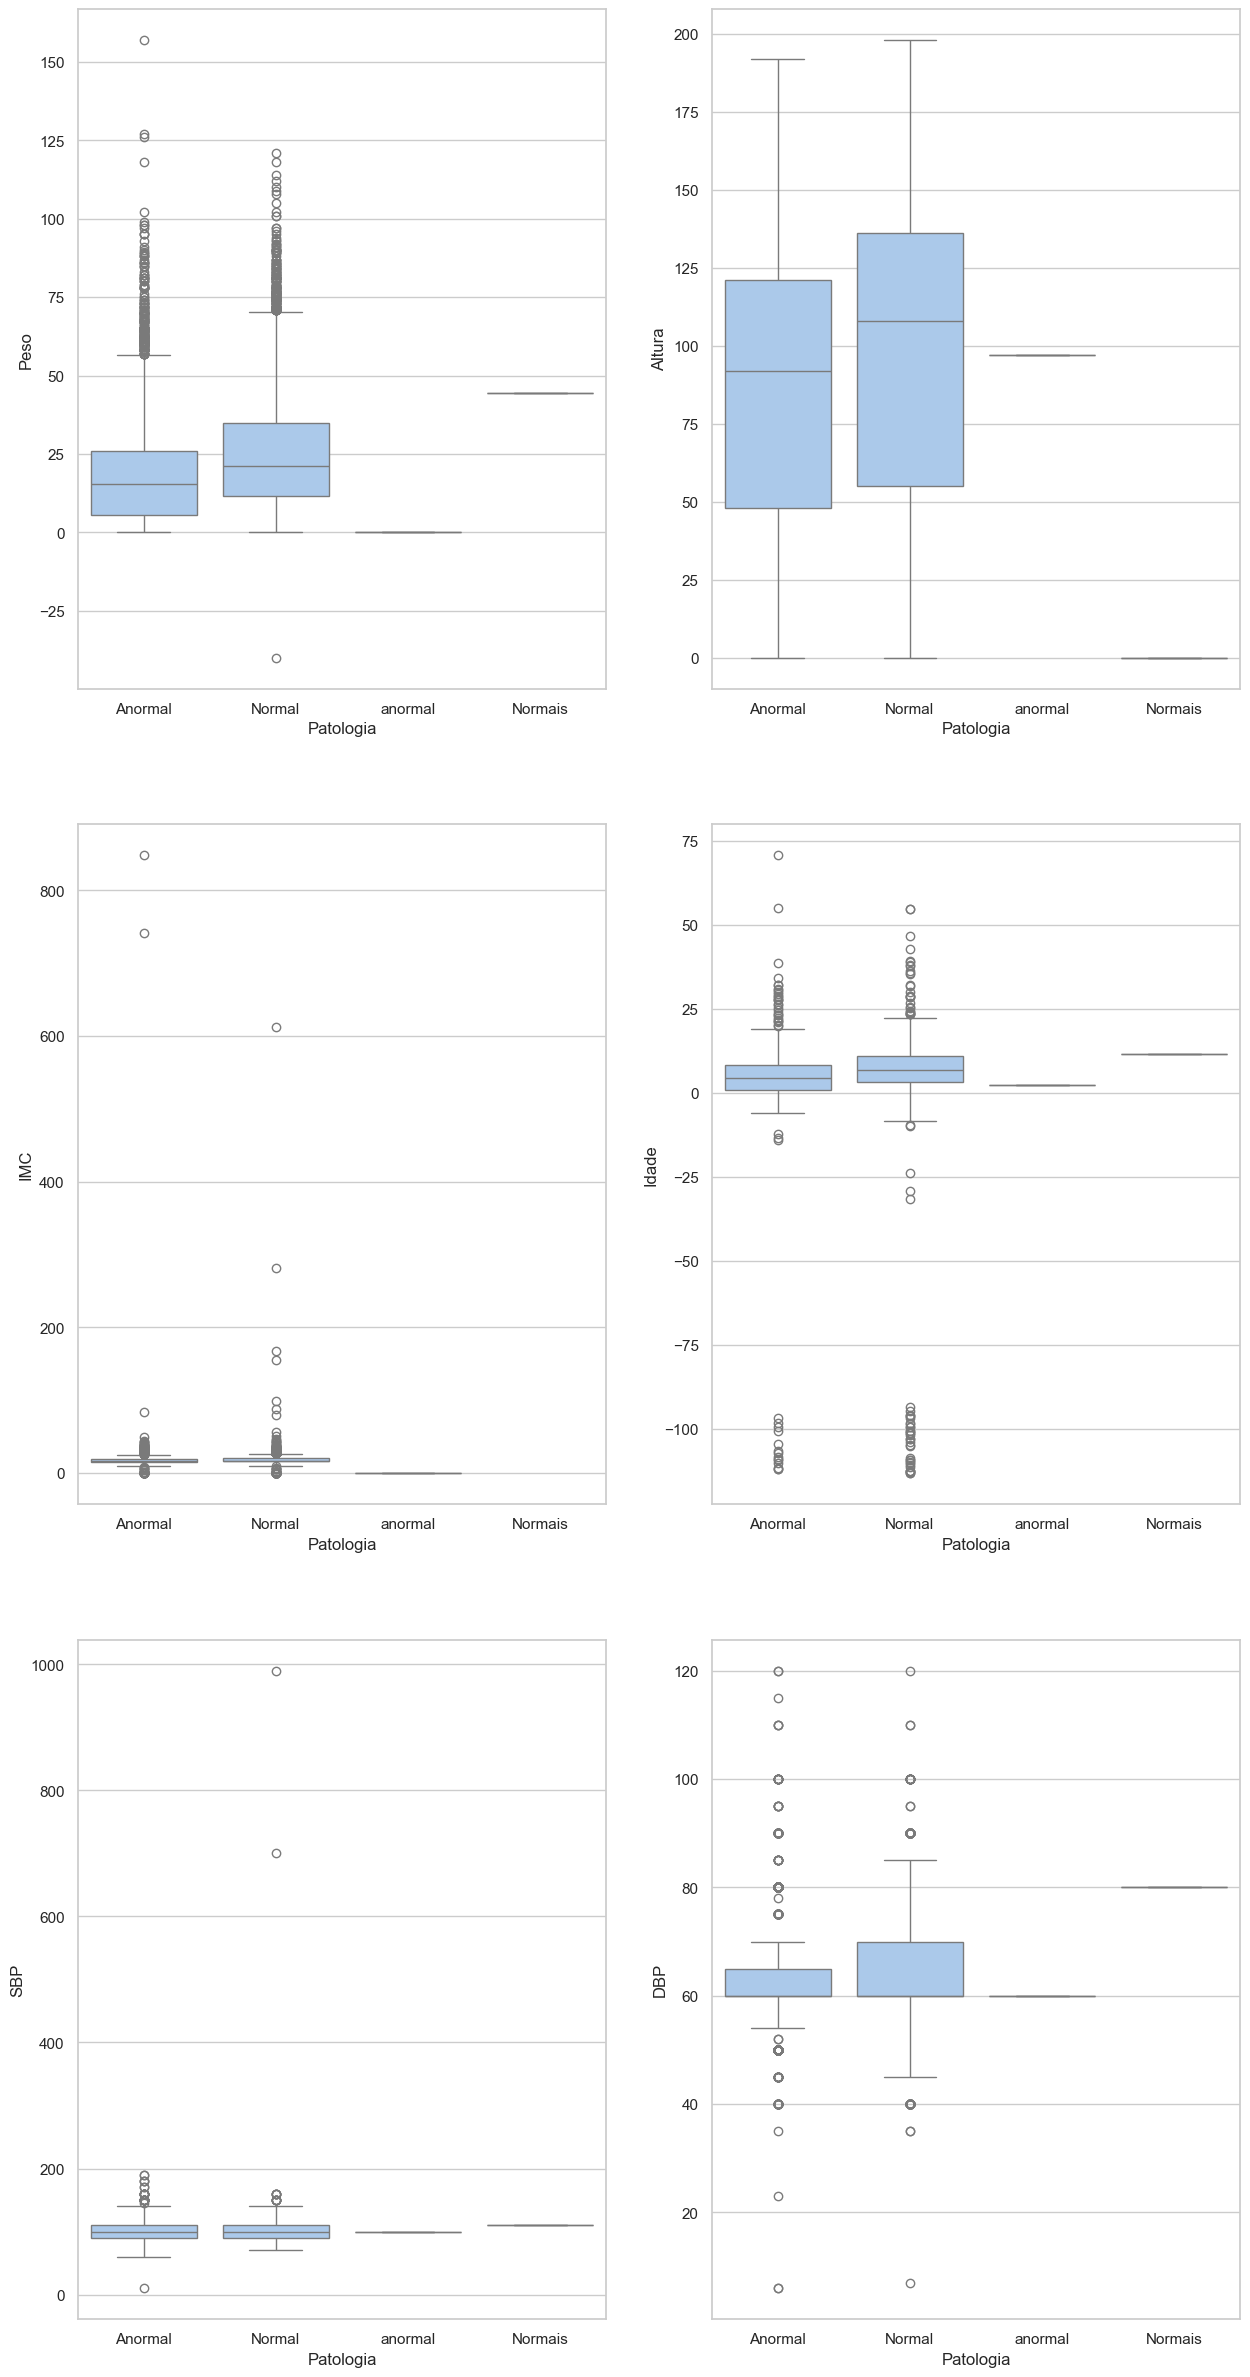

In [17]:
def graph(y):
    sns.boxplot(x="Patologia", y=y, data=data)


plt.figure(figsize=(15,30))


# Boxplot de variaveis númerica contra target feature (NORMAL X ANORMAL)
plt.subplot(321)
graph('Peso')
plt.subplot(322)
graph('Altura')
plt.subplot(323)
graph('IMC')
plt.subplot(324)
graph('Idade')
plt.subplot(325)
graph('SBP')
plt.subplot(326)
graph('DBP')

* Com os gráficos acima podemos observar :
    * A distibuição das features númericos face a respetiva "classe" da target feature.
    * Os valores 'anormal' e 'Normais' são "erros de inserção", porque só existe um de cada (dai o boxplot achatado)
    * verificamos a presença dos outliers que em certos casos são valores impossiveis

#### 2.3.4 Spread measures 

As **Spread measures** dizem-nos quão **"espalhados"** ou **"concentrados"** os dados estão à volta desse centro.


| Medida | Definição | Utilidade | Observações |
| :--- | :--- | :--- | :--- |
| **Amplitude** | Máximo - Mínimo | Largura total dos dados | Sensível a outliers |
| **IQR** | $Q3 - Q1$ | O IQR representa a amplitude dos 50% "centrais" dos seus dados. | Robusta contra outliers |
| **Variância** | Média dos desvios ao quadrado | Mede "qual é, em média, o quadrado da distância de cada ponto até à média"| Unidade ao quadrado |
| **Desvio Padrão** | $\sqrt{\text{Variância}}$ | Distância média até à média. Diz-nos, em média, o quão longe cada ponto de dados está da média do conjunto. | Medida padrão de dispersão |
| **Coef. Variação** | $(DP / \text{Média}) \times 100\%$ | Comparação entre grupos. Permite comparar a variabilidade de dois conjuntos de dados diferentes, mesmo que tenham médias ou unidades de medida distintas. | Dispersão relativa |

In [32]:
# SUB-PLOT 1 (Boxplot): Foca na estatística posicional. Visualiza o IQR (50% centrais), 
# amplitude, outliers e assimetria (comparação entre média e mediana).

# SUB-PLOT 2 (Histograma/KDE): Foca na forma e densidade. A curva KDE indica o 
# espalhamento, enquanto as linhas verticais delimitam o Desvio Padrão, 
# zona de maior probabilidade( correspondem 68% dos dados).

# MÉTRICAS: Painel lateral com Amplitude, IQR, Variância, DP e CV (dispersão relativa).

def plot_spread_measures(df, variable, stats):
    """

    Visualização combinada de dispersão:
        1. Boxplot: Identifica quartis (IQR), limites de amplitude e outliers.
        2. Histograma/KDE: Exibe a silhueta da distribuição e a dispersão em torno da média (DP).
        3. Estatísticas: Sumário numérico das principais métricas de variabilidade.
        
    Argumentos:
        df (pd.DataFrame): O conjunto de dados original.
        variable (str): Nome da coluna numérica a ser analisada.
        stats (dict): Dicionário com métricas pré-calculadas (media, std, iqr, etc.).
        
    Retorna:
        Um gráfico com Boxplot (foco em quartis e outliers) e 
        Histograma (foco em densidade e desvio padrão).
    """
    
    # Configuração da Figura
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                           gridspec_kw={"height_ratios": (.15, .85)}, 
                                           figsize=(10, 6))
    
    # Boxplot (usando os dados brutos para os quartis automáticos)
    sns.boxplot(x=df[variable], ax=ax_box, color='lightgreen', showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
    ax_box.set(xlabel='')
    ax_box.set_title(f'Análise de Dispersão: {variable}', fontsize=14)
    
    # 2. Histograma
    sns.histplot(df[variable], kde=True, ax=ax_hist, color='lightgreen', stat="density")
    
    # Linhas de referência usando os argumentos passados
    media = stats['media']
    std = stats['std']
    
    ax_hist.axvline(media, color='red', linestyle='--', label=f"Média: {media:.2f}")
    ax_hist.axvline(media + std, color='orange', linestyle=':', label=f"Média ± 1 Desvio Padrão")
    ax_hist.axvline(media - std, color='orange', linestyle=':')
    
    # 3. Caixa de Texto com as medidas externas
    textstr = '\n'.join((
        f"Amplitude: {stats['amplitude']:.2f}",
        f"IQR: {stats['iqr']:.2f}",
        f"Variância: {stats['variancia']:.2f}",
        f"Desvio Padrão: {std:.2f}",
        f"CV: {stats['cv']:.2f}%"
    ))
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax_hist.text(0.02, 0.95, textstr, transform=ax_hist.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

    ax_hist.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

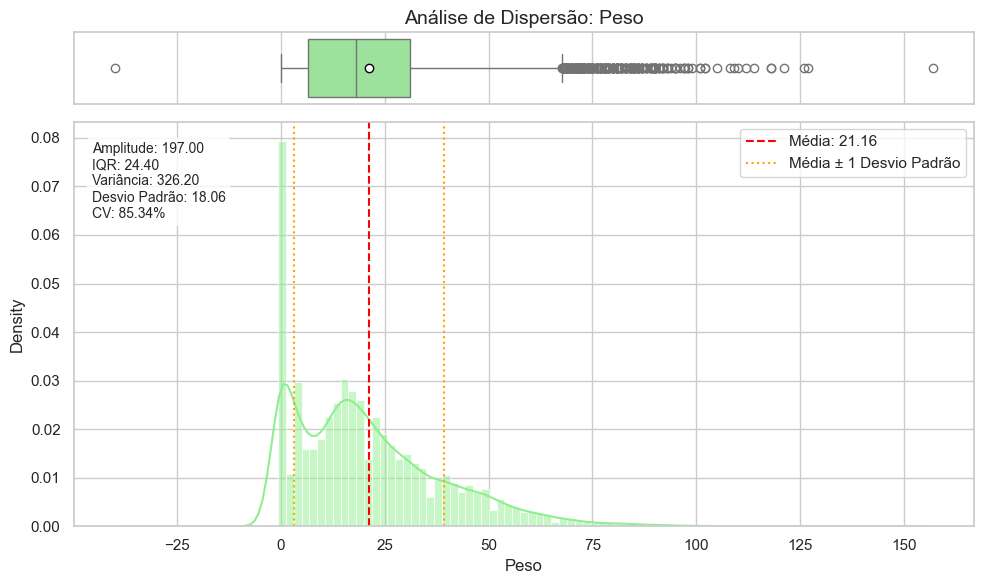

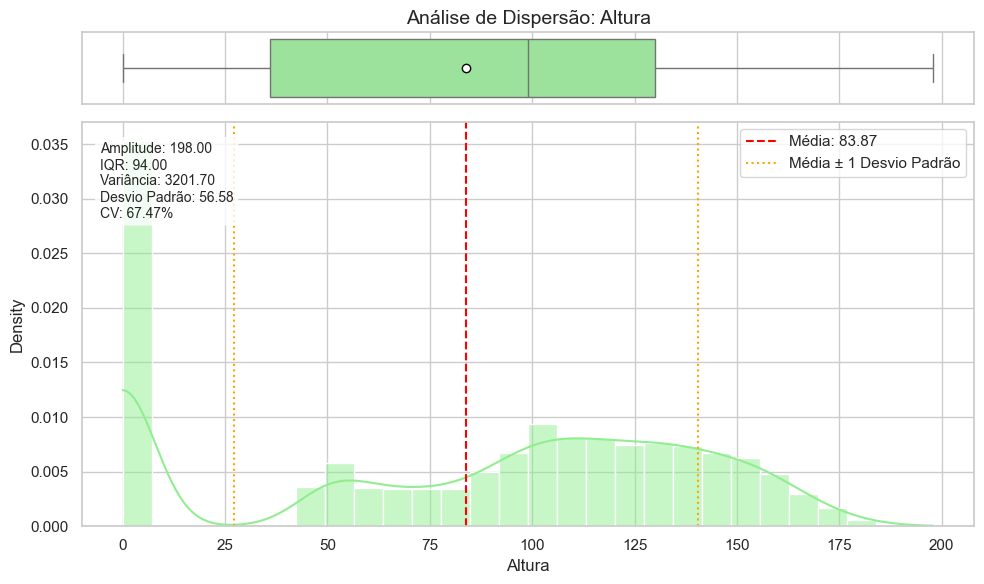

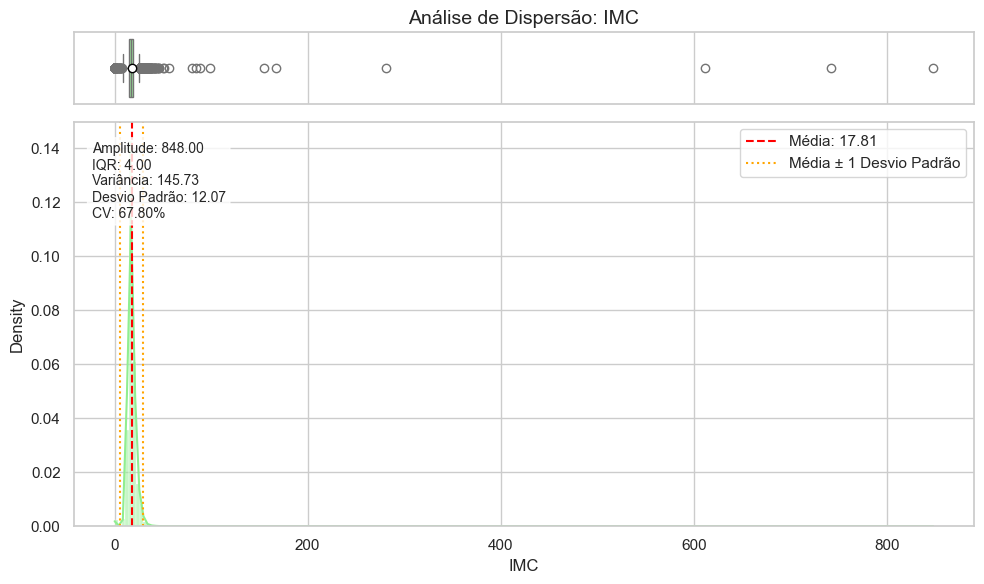

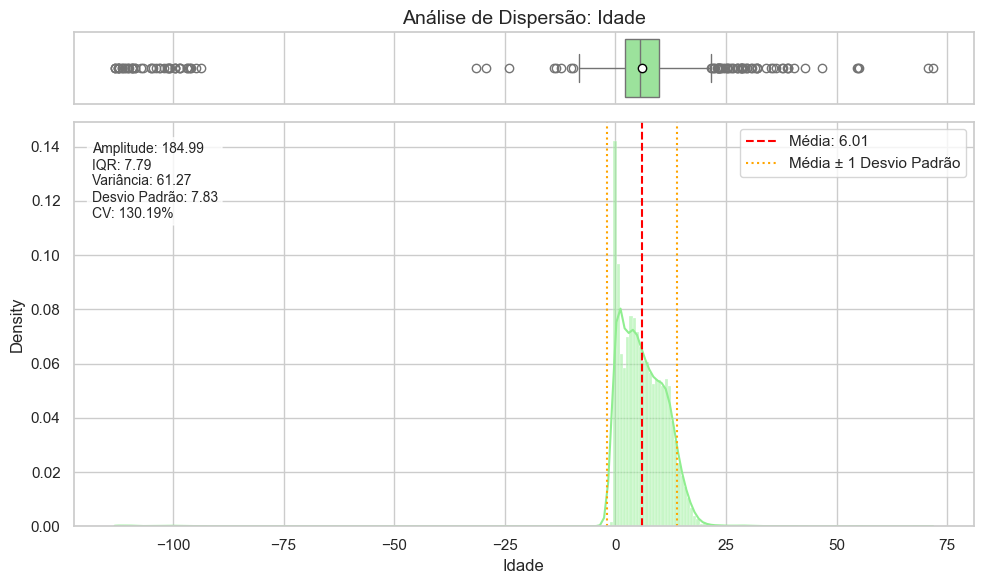

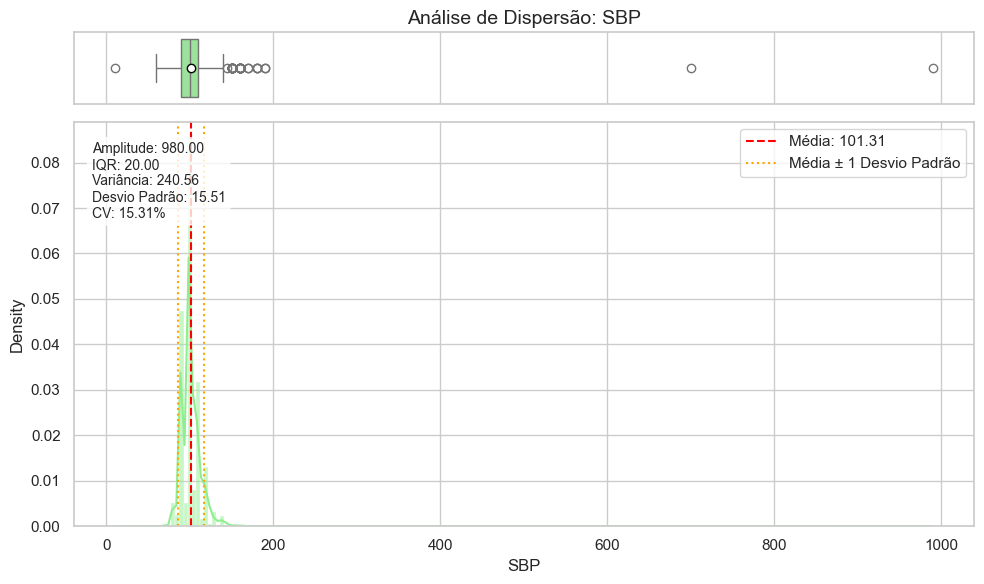

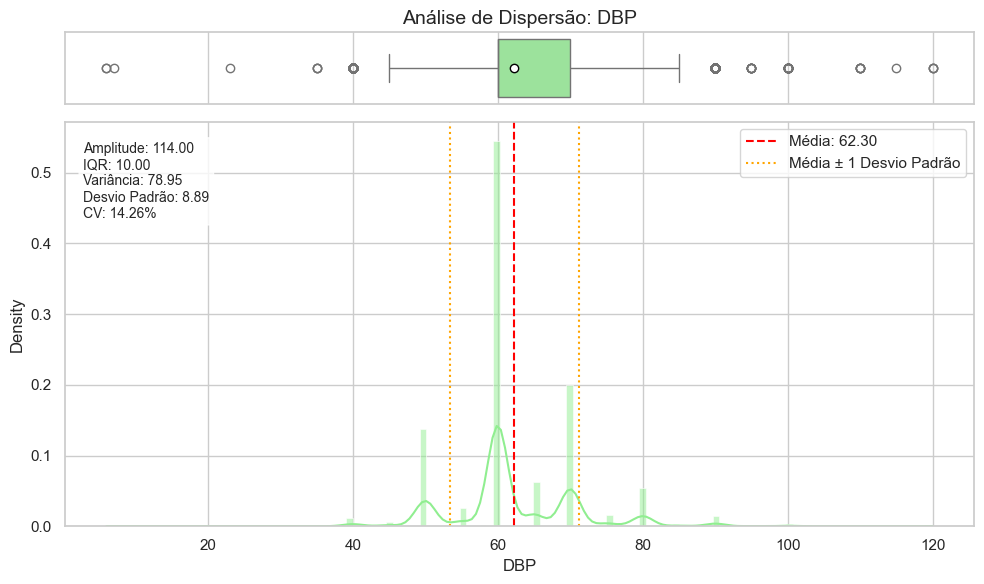

In [30]:
# Só podemos medir a dispersão de medidas númericas
variaveis_numericas = ['Peso','Altura','IMC','Idade','SBP','DBP']

for variable in variaveis_numericas:
    q1 = data[variable].quantile(0.25)
    q3 = data[variable].quantile(0.75)
    desvio_padrao = data[variable].std()
    media = data[variable].mean()

    # Organizando os resultados para a função
    medidas = {
        'amplitude': data[variable].max() - data[variable].min(),
        'iqr': q3 - q1,
        'variancia': data[variable].var(),
        'std': desvio_padrao,
        'media': media,
        'cv': (desvio_padrao / media) * 100
    }

    plot_spread_measures(data, variable, medidas)

#### 2.3.5 Density 

TODO

#### 2.3.6 Correlation

TODO

## 3. List of main changes needed to be performed with the raw data.

Prepare the raw data for modeling by fixing errors, handling missing values and transforming it into a clean and usable form.

* Remove duplicates and correct inconsistent or incorrect entries.
* Handle missing values using imputation, deletion or interpolation techniques.
* Normalize or scale numerical features for stable and faster model training.
* Encode categorical variables using Label Encoding, One-Hot Encoding or Target Encoding.